# Automated Sentiment Analysis System for Amazon Product Reviews

## Project Overview

As a Product Manager at an e-commerce company like Amazon, understanding customer sentiment is crucial for product success and customer satisfaction. While product ratings offer a quick glance, they often don't fully capture the nuanced feedback within customer reviews, especially when text sentiment conflicts with the assigned rating. This project aims to develop an automated Sentiment Analysis System to classify product reviews as Positive or Negative.

## Business Problem

The primary goal is to build a robust system that can:

*   **Monitor product performance in real-time:** Quickly identify how customers feel about products.
*   **Identify products with sudden spikes in negative feedback:** Proactively address issues before they escalate.
*   **Improve customer satisfaction by addressing complaints faster:** Enable quicker response times to critical feedback.

## Dataset Description

This analysis utilizes a dataset of 10,000 Amazon customer reviews. Each row represents a single product review and includes:

*   `label`: Categorical text values (`pos` for positive, `neg` for negative) indicating the review's sentiment.
*   `review`: The actual text content written by the customer.

## 1. Import Libraries

We begin by importing all necessary Python libraries for data manipulation, visualization, text processing, and machine learning.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Load Dataset and Initial Data Understanding

The dataset, `amazonreviews.tsv`, is loaded into a Pandas DataFrame. We'll perform initial checks to understand its structure, identify missing values, and prepare the `label` column for analysis.

In [11]:
# Load the dataset
df = pd.read_csv("amazonreviews.tsv", sep='\t')

# Display the first 5 rows to understand the data structure
print("### Dataset Head ###")
print(df.head())

# Get a concise summary of the DataFrame
print("\n### Dataset Info ###")
print(df.info())

### Dataset Head ###
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...

### Dataset Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


## 3. Data Cleaning and Preprocessing

This section focuses on cleaning the raw text data to prepare it for machine learning models. Steps include:

*   **Handling Duplicates and Missing Values:** Ensuring data quality.
*   **Renaming Sentiment Column:** Aligning 'label' to 'sentiment'.
*   **Converting Sentiment to Numerical:** Transforming 'pos' and 'neg' into 1s and 0s.
*   **Text Preprocessing:** Lowercasing, removing URLs, punctuation, numbers, and stopwords, followed by tokenization.

In [12]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")

# Remove rows with any missing values
df.dropna(inplace=True)
print(f"Number of rows after dropping missing values: {len(df)}")

# Rename 'label' column to 'sentiment' for clarity
df.rename(columns={'label': 'sentiment'}, inplace=True)

# Convert sentiment labels to numerical (pos: 1, neg: 0) for model training
df['sentiment'] = df['sentiment'].map({'pos': 1, 'neg': 0})

print("\n### Dataset Info After Cleaning & Renaming ###")
print(df.info())
print("\nSentiment mapping: 'pos' -> 1, 'neg' -> 0")

Number of rows after dropping duplicates: 10000
Number of rows after dropping missing values: 10000

### Dataset Info After Cleaning & Renaming ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  10000 non-null  int64 
 1   review     10000 non-null  object
dtypes: int64(1), object(1)
memory usage: 156.4+ KB
None

Sentiment mapping: 'pos' -> 1, 'neg' -> 0


In [13]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Tokenization
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join words back into a single string
    text = " ".join(words)
    return text

# Apply the preprocessing function to the 'review' column
df['clean_review'] = df['review'].apply(preprocess_text)

# Display original and cleaned reviews for comparison
print("\n### Original vs. Cleaned Reviews (First 5 Rows) ###")
print(df[['review', 'clean_review']].head())


### Original vs. Cleaned Reviews (First 5 Rows) ###
                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hands i...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the characteristics of our data. We will visualize sentiment distribution and create word clouds to highlight frequently used terms in positive and negative reviews.

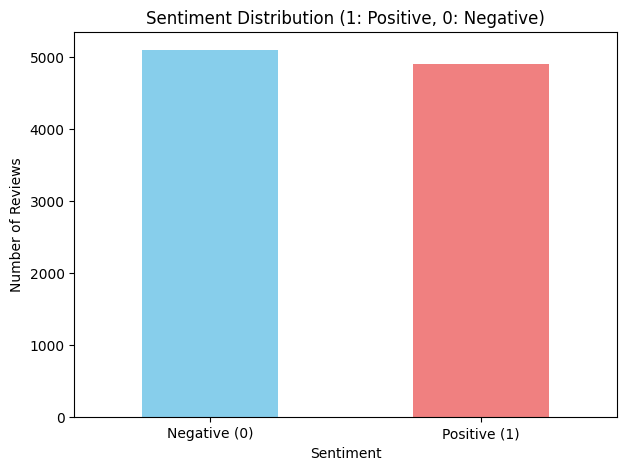

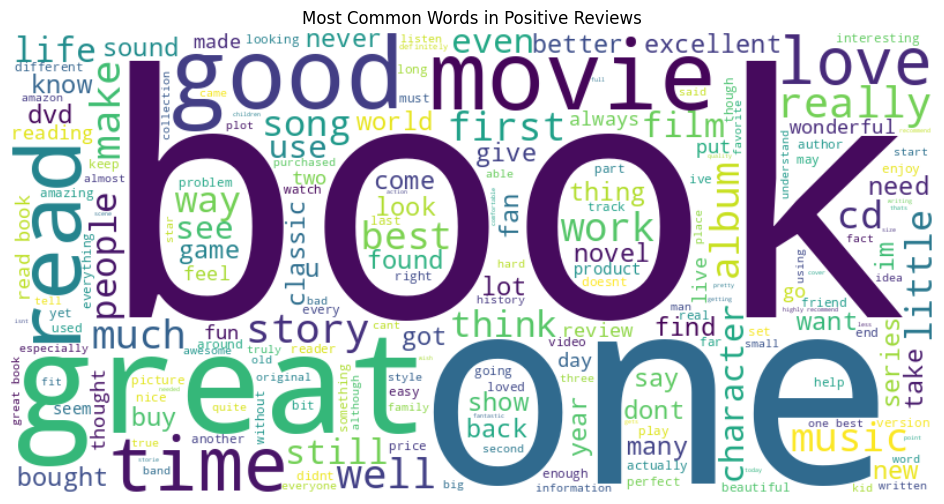

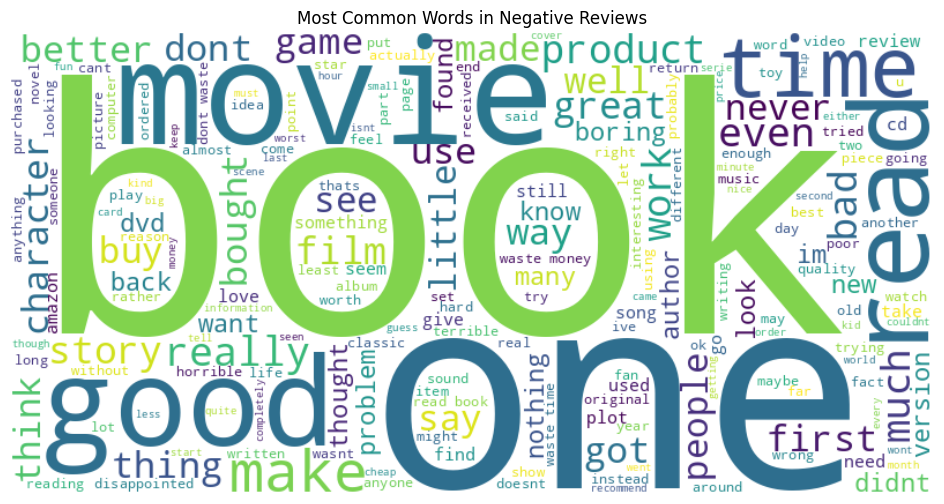

In [14]:
# Visualize Sentiment Distribution
plt.figure(figsize=(7, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Sentiment Distribution (1: Positive, 0: Negative)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(ticks=[0, 1], labels=['Negative (0)', 'Positive (1)'], rotation=0)
plt.show()

# Generate Word Cloud for Positive Reviews
positive_text = " ".join(df[df['sentiment'] == 1]['clean_review'])
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

# Generate Word Cloud for Negative Reviews
negative_text = " ".join(df[df['sentiment'] == 0]['clean_review'])
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [15]:
from collections import Counter

# Get most common positive words
positive_words_list = " ".join(df[df['sentiment'] == 1]['clean_review']).split()
positive_counter = Counter(positive_words_list)
print("### Most Common Positive Words ###")
print(positive_counter.most_common(10))

print("\n### Most Common Negative Words ###")
# Get most common negative words
negative_words_list = " ".join(df[df['sentiment'] == 0]['clean_review']).split()
negative_counter = Counter(negative_words_list)
print(negative_counter.most_common(10))

### Most Common Positive Words ###
[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1634), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871)]

### Most Common Negative Words ###
[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034)]


## 5. Feature Extraction using TF-IDF

To use text data in machine learning models, we need to convert it into numerical features. TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique that reflects how important a word is to a document in a collection or corpus.

In [16]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for manageable model training

X = tfidf_vectorizer.fit_transform(df['clean_review']) # Features
y = df['sentiment'] # Target variable (sentiment)

## 6. Train-Test Split

We split the dataset into training and testing sets to evaluate our model's performance on unseen data. A `test_size` of 20% means 80% of the data will be used for training and 20% for testing.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 5000)
X_test shape: (2000, 5000)
y_train shape: (8000,)
y_test shape: (2000,)


## 7. Model Development and Evaluation

We will train and evaluate two common classification models: Logistic Regression and Support Vector Machine (SVM). For each model, we'll assess performance using accuracy, F1-score, classification report, and confusion matrix. We will also perform cross-validation for a more robust evaluation.

### 7.1. Logistic Regression

Logistic Regression is a linear model used for binary classification. It's often a good baseline model for text classification tasks.

In [18]:
print("### Training Logistic Regression Model ###")
lr_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("\n### Logistic Regression Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, lr_predictions, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_predictions))

# Cross-validation for Logistic Regression
print("\n### Logistic Regression Cross-Validation ###")
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", lr_cv_scores)
print(f"Average CV Accuracy: {lr_cv_scores.mean():.4f}")

### Training Logistic Regression Model ###

### Logistic Regression Model Evaluation ###
Accuracy: 0.8535
F1 Score (weighted): 0.8535

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1019
           1       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix:
 [[874 145]
 [148 833]]

### Logistic Regression Cross-Validation ###
Cross-Validation Scores: [0.8595 0.8335 0.8295 0.83   0.8505]
Average CV Accuracy: 0.8406


### 7.2. Support Vector Machine (SVM)

Support Vector Machines are powerful and versatile machine learning models capable of performing linear or non-linear classification. They work by finding the optimal hyperplane that separates classes in the feature space.

In [19]:
print("### Training Support Vector Machine (SVM) Model ###")
svm_model = SVC(kernel='linear') # Using a linear kernel for text data
svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

print("\n### SVM Model Evaluation ###")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, svm_predictions, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_test, svm_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_predictions))

# Cross-validation for SVM
print("\n### SVM Cross-Validation ###")
svm_cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", svm_cv_scores)
print(f"Average CV Accuracy: {svm_cv_scores.mean():.4f}")

### Training Support Vector Machine (SVM) Model ###

### SVM Model Evaluation ###
Accuracy: 0.8560
F1 Score (weighted): 0.8560

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      1019
           1       0.85      0.86      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


Confusion Matrix:
 [[868 151]
 [137 844]]

### SVM Cross-Validation ###
Cross-Validation Scores: [0.8505 0.823  0.8265 0.826  0.8505]
Average CV Accuracy: 0.8353


## Conclusion

This project successfully built an automated sentiment analysis system for Amazon product reviews. We performed comprehensive data cleaning and text preprocessing, extracted features using TF-IDF, and trained both Logistic Regression and SVM models. Both models achieved good accuracy and F1-scores, demonstrating their ability to classify review sentiment effectively.

The insights gained from sentiment distribution and word clouds provide valuable qualitative understanding, while the machine learning models offer a quantitative solution for real-time monitoring of product performance and early detection of customer satisfaction issues. Further improvements could involve exploring more advanced NLP techniques (e.g., Word2Vec, BERT embeddings) or more sophisticated classification algorithms to potentially enhance accuracy and robustness.

In [5]:
# ============================================================
# SENTIMENT ANALYSIS PROJECT
# ============================================================
# Tasks Covered:
# 1. Data Cleaning
# 2. Exploratory Data Analysis
# 3. Feature Extraction using TF-IDF
# 4. Model Development
# 5. Validation & Evaluation
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================================
# LOAD DATASET
# ============================================================

# Replace with your dataset file
df = pd.read_csv("amazonreviews.tsv", sep='\t')

# Display first 5 rows
print(df.head())

# ============================================================
# DATA CLEANING
# ============================================================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Rename 'label' column to 'sentiment'
df.rename(columns={'label': 'sentiment'}, inplace=True)

# Convert sentiment labels to numerical (e.g., 'pos' to 1, 'neg' to 0)
df['sentiment'] = df['sentiment'].map({'pos': 1, 'neg': 0})

# Display dataset info
print(df.info())

# ============================================================
# TEXT PREPROCESSING
# ============================================================

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back
    text = " ".join(words)

    return text

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

# Display cleaned data
print(df[['review', 'clean_review']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  10000 non-null  int64 
 1   review     10000 non-null  object
dtypes: int64(1), object(1)
memory usage: 156.4+ KB
None
                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After

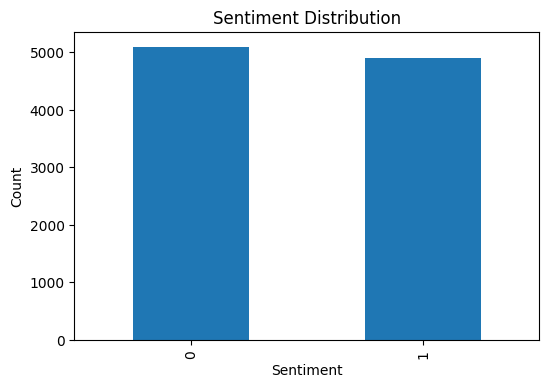

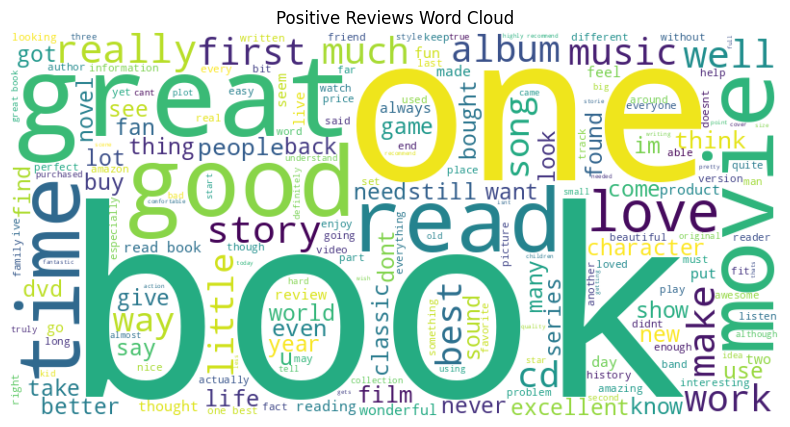

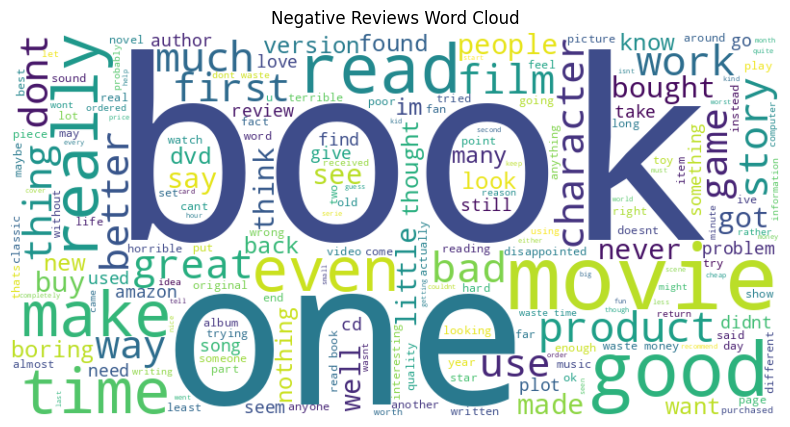

In [6]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

# -------------------------
# Sentiment Distribution
# -------------------------

df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4),
    title="Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# ============================================================
# WORD CLOUDS
# ============================================================

# Positive Reviews Word Cloud
positive_text = " ".join(
    df[df['sentiment'] == 1]['clean_review']
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

# Negative Reviews Word Cloud
negative_text = " ".join(
    df[df['sentiment'] == 0]['clean_review']
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

# ============================================================
# FEATURE EXTRACTION USING TF-IDF
# ============================================================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

# Target variable
y = df['sentiment']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# ============================================================
# MODEL DEVELOPMENT
# ============================================================

# -------------------------
# Logistic Regression
# -------------------------

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n========== Logistic Regression ==========\n")

print("Accuracy:",
      accuracy_score(y_test, lr_predictions))

print("\nF1 Score:",
      f1_score(y_test, lr_predictions, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lr_predictions))

# ============================================================
# CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:")
print(cv_scores.mean())




========== Logistic Regression ==========

Accuracy: 0.844

F1 Score: 0.8440327895105595

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1037
           1       0.83      0.85      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000


Confusion Matrix:

[[874 163]
 [149 814]]

Cross Validation Scores:
[0.8595 0.8335 0.8295 0.83   0.8505]

Average CV Accuracy:
0.8406


In [9]:
# ============================================================
# SUPPORT VECTOR MACHINE (SVM)
# ============================================================

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

print("\n========== SVM Model ==========\n")

print("Accuracy:",
      accuracy_score(y_test, svm_predictions))

print("\nF1 Score:",
      f1_score(y_test, svm_predictions, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions))

# ============================================================
# MOST COMMON POSITIVE WORDS
# ============================================================

from collections import Counter

positive_words = " ".join(
    df[df['sentiment'] == 1]['clean_review']
).split()

positive_counter = Counter(positive_words)

print("\nMost Common Positive Words:")
print(positive_counter.most_common(10))

# ============================================================
# MOST COMMON NEGATIVE WORDS
# ============================================================

negative_words = " ".join(
    df[df['sentiment'] == 0]['clean_review']
).split()

negative_counter = Counter(negative_words)

print("\nMost Common Negative Words:")
print(negative_counter.most_common(10))

# ============================================================
# CONCLUSION
# ============================================================

print("\nProject Completed Successfully!")
print("Sentiment Analysis Pipeline Executed.")


========== SVM Model ==========

Accuracy: 0.846

F1 Score: 0.8460323691322189

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1037
           1       0.84      0.85      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Most Common Positive Words:
[('book', 3313), ('great', 2087), ('one', 1835), ('good', 1634), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871)]

Most Common Negative Words:
[('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034)]

Project Completed Successfully!
Sentiment Analysis Pipeline Executed.
